# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)




,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


In [4]:
# EDA

# Các cột mô tả bối cảnh, chỉ dùng để kiểm tra sau khi clustering
context_columns = [
    column for column in ['Channel', 'Region']
    if column in df.columns
]

print('=== 1. TỔNG QUAN DỮ LIỆU ===')
print(f'Số khách hàng              : {df.shape[0]}')
print(f'Tổng số cột                : {df.shape[1]}')
print(f'Số feature dùng clustering : {len(SPENDING_FEATURES)}')
print(f'Feature clustering          : {SPENDING_FEATURES}')
print(f'Cột context                 : {context_columns}')
print()


# ------------------------------------------------------------
# 2. Kiểm tra kiểu dữ liệu và giá trị thiếu
# ------------------------------------------------------------
audit_table = pd.DataFrame({
    'dtype': df[SPENDING_FEATURES].dtypes.astype(str),
    'missing_count': df[SPENDING_FEATURES].isna().sum(),
    'missing_percent': (
        df[SPENDING_FEATURES].isna().mean() * 100
    ),
    'unique_values': df[SPENDING_FEATURES].nunique(),
    'minimum': df[SPENDING_FEATURES].min(),
    'maximum': df[SPENDING_FEATURES].max(),
    'mean': df[SPENDING_FEATURES].mean(),
    'median': df[SPENDING_FEATURES].median(),
    'std': df[SPENDING_FEATURES].std(),
    'skewness': df[SPENDING_FEATURES].skew()
})

print('=== 2. AUDIT TỪNG FEATURE ===')
display(audit_table.round(2))




=== 1. TỔNG QUAN DỮ LIỆU ===
Số khách hàng              : 440
Tổng số cột                : 7
Số feature dùng clustering : 6
Feature clustering          : ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Cột context                 : ['Channel']

=== 2. AUDIT TỪNG FEATURE ===


,dtype,missing_count,missing_percent,unique_values,minimum,maximum,mean,median,std,skewness
Fresh,int64,0,0.00,433,3,112151,"12,000.30","8,504.00","12,647.33",2.56
Milk,int64,0,0.00,421,55,73498,"5,796.27","3,627.00","7,380.38",4.05
Grocery,int64,0,0.00,430,3,92780,"7,951.28","4,755.50","9,503.16",3.59
Frozen,int64,0,0.00,426,25,60869,"3,071.93","1,526.00","4,854.67",5.91
Detergents_Paper,int64,0,0.00,417,3,40827,"2,881.49",816.50,"4,767.85",3.63
Delicassen,int64,0,0.00,403,3,47943,"1,524.87",965.50,"2,820.11",11.15


In [5]:
# ------------------------------------------------------------
# 3. Kiểm tra duplicate
# ------------------------------------------------------------
full_duplicate_count = int(df.duplicated().sum())
spending_duplicate_count = int(X_raw.duplicated().sum())

print('=== 3. KIỂM TRA BẢN GHI TRÙNG LẶP ===')
print(f'Số dòng trùng hoàn toàn             : {full_duplicate_count}')
print(f'Số dòng trùng trên 6 feature chi tiêu: {spending_duplicate_count}')
print()

=== 3. KIỂM TRA BẢN GHI TRÙNG LẶP ===
Số dòng trùng hoàn toàn             : 0
Số dòng trùng trên 6 feature chi tiêu: 0



In [6]:
# ------------------------------------------------------------
# 4. Kiểm tra giá trị không hợp lệ hoặc cần chú ý
# ------------------------------------------------------------
value_check = pd.DataFrame({
    'negative_count': (X_raw < 0).sum(),
    'zero_count': (X_raw == 0).sum(),
    'zero_percent': (X_raw == 0).mean() * 100
})

print('=== 4. KIỂM TRA GIÁ TRỊ ÂM VÀ GIÁ TRỊ 0 ===')
display(value_check.round(2))

=== 4. KIỂM TRA GIÁ TRỊ ÂM VÀ GIÁ TRỊ 0 ===


,negative_count,zero_count,zero_percent
Fresh,0,0,0.00
Milk,0,0,0.00
Grocery,0,0,0.00
Frozen,0,0,0.00
Detergents_Paper,0,0,0.00
Delicassen,0,0,0.00


In [7]:
# ------------------------------------------------------------
# 5. Phát hiện điểm cực lớn bằng quy tắc IQR
# Chỉ đánh dấu để nghiên cứu, chưa tự động xóa.
# ------------------------------------------------------------
q1 = X_raw.quantile(0.25)
q3 = X_raw.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_outlier_mask = (
    (X_raw < lower_bound) |
    (X_raw > upper_bound)
)

outlier_table = pd.DataFrame({
    'Q1': q1,
    'Q3': q3,
    'IQR': iqr,
    'lower_bound': lower_bound,
    'upper_bound': upper_bound,
    'outlier_count': iqr_outlier_mask.sum(),
    'outlier_percent': iqr_outlier_mask.mean() * 100
})

print('=== 5. ĐIỂM CỰC LỚN THEO QUY TẮC IQR ===')
display(outlier_table.round(2))

customers_with_outlier = iqr_outlier_mask.any(axis=1)
print(
    'Số khách hàng có ít nhất một feature nằm ngoài ngưỡng IQR:',
    int(customers_with_outlier.sum())
)
print(
    'Tỷ lệ khách hàng có ít nhất một feature nằm ngoài ngưỡng IQR:',
    f'{customers_with_outlier.mean() * 100:.2f}%'
)
print()

=== 5. ĐIỂM CỰC LỚN THEO QUY TẮC IQR ===


,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
Fresh,"3,127.75","16,933.75","13,806.00","-17,581.25","37,642.75",20,4.55
Milk,"1,533.00","7,190.25","5,657.25","-6,952.88","15,676.12",28,6.36
Grocery,"2,153.00","10,655.75","8,502.75","-10,601.12","23,409.88",24,5.45
Frozen,742.25,"3,554.25","2,812.00","-3,475.75","7,772.25",43,9.77
Detergents_Paper,256.75,"3,922.00","3,665.25","-5,241.12","9,419.88",30,6.82
Delicassen,408.25,"1,820.25","1,412.00","-1,709.75","3,938.25",27,6.14


Số khách hàng có ít nhất một feature nằm ngoài ngưỡng IQR: 108
Tỷ lệ khách hàng có ít nhất một feature nằm ngoài ngưỡng IQR: 24.55%



In [8]:

# ------------------------------------------------------------
# 6. Kiểm tra phân phối có bị lệch mạnh hay không
# ------------------------------------------------------------
skewness = X_raw.skew().sort_values(ascending=False)

print('=== 6. ĐỘ LỆCH PHÂN PHỐI ===')
display(
    skewness.rename('skewness').to_frame().round(2)
)

strongly_skewed_features = skewness[
    skewness.abs() > 1
].index.tolist()

print(
    'Các feature có |skewness| > 1:',
    strongly_skewed_features
)
print(
    'Nhận xét: nếu nhiều feature lệch phải mạnh, '
    'có thể thử log1p trước khi scale và clustering.'
)
print()


# ------------------------------------------------------------
# 7. Kiểm tra Channel và Region để dùng cho profiling sau này
# ------------------------------------------------------------
if context_columns:
    print('=== 7. PHÂN BỐ CÁC BIẾN CONTEXT ===')

    for column in context_columns:
        context_summary = pd.DataFrame({
            'count': df[column].value_counts().sort_index(),
            'percent': (
                df[column].value_counts(
                    normalize=True
                ).sort_index() * 100
            )
        })

        print(f'\nPhân bố của {column}:')
        display(context_summary.round(2))


# ------------------------------------------------------------
# 8. Kết luận audit tự động
# ------------------------------------------------------------
print('=== 8. KẾT LUẬN AUDIT ===')

total_missing = int(X_raw.isna().sum().sum())
total_negative = int((X_raw < 0).sum().sum())

print(f'- Tổng số giá trị thiếu: {total_missing}')
print(f'- Tổng số giá trị âm: {total_negative}')
print(f'- Số dòng trùng hoàn toàn: {full_duplicate_count}')
print(f'- Feature lệch mạnh: {strongly_skewed_features}')

if total_missing == 0:
    print('- Không cần xử lý missing value trước khi clustering.')
else:
    print('- Cần xử lý missing value trước khi clustering.')

if total_negative == 0:
    print('- Không phát hiện mức chi tiêu âm.')
else:
    print('- Cần kiểm tra các giá trị chi tiêu âm.')

if strongly_skewed_features:
    print(
        '- Dữ liệu có phân phối lệch mạnh; '
        'nên so sánh ít nhất hai preprocessing pipeline:'
    )
    print('  1. StandardScaler hoặc RobustScaler trên dữ liệu gốc.')
    print('  2. log1p sau đó StandardScaler hoặc RobustScaler.')

print(
    '- Không tự động xóa outlier ở bước này vì khách hàng '
    'chi tiêu rất lớn có thể là một phân khúc kinh doanh quan trọng.'
)

=== 6. ĐỘ LỆCH PHÂN PHỐI ===


,skewness
Delicassen,11.15
Frozen,5.91
Milk,4.05
Detergents_Paper,3.63
Grocery,3.59
Fresh,2.56


Các feature có |skewness| > 1: ['Delicassen', 'Frozen', 'Milk', 'Detergents_Paper', 'Grocery', 'Fresh']
Nhận xét: nếu nhiều feature lệch phải mạnh, có thể thử log1p trước khi scale và clustering.

=== 7. PHÂN BỐ CÁC BIẾN CONTEXT ===

Phân bố của Channel:


,count,percent
Channel,,
1,298,67.73
2,142,32.27


=== 8. KẾT LUẬN AUDIT ===
- Tổng số giá trị thiếu: 0
- Tổng số giá trị âm: 0
- Số dòng trùng hoàn toàn: 0
- Feature lệch mạnh: ['Delicassen', 'Frozen', 'Milk', 'Detergents_Paper', 'Grocery', 'Fresh']
- Không cần xử lý missing value trước khi clustering.
- Không phát hiện mức chi tiêu âm.
- Dữ liệu có phân phối lệch mạnh; nên so sánh ít nhất hai preprocessing pipeline:
  1. StandardScaler hoặc RobustScaler trên dữ liệu gốc.
  2. log1p sau đó StandardScaler hoặc RobustScaler.
- Không tự động xóa outlier ở bước này vì khách hàng chi tiêu rất lớn có thể là một phân khúc kinh doanh quan trọng.


### Nhận xét và định nghĩa bài toán

Mỗi dòng đại diện cho một khách hàng của nhà phân phối. Sáu cột `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper` và `Delicassen` là mức chi tiêu hằng năm, vì vậy chúng là các đặc trưng phù hợp để tìm nhóm hành vi mua hàng.

Dữ liệu không có giá trị thiếu, giá trị âm, giá trị 0 hay dòng trùng. Tuy nhiên, 108 khách hàng (24,55%) có ít nhất một điểm ngoài ngưỡng IQR và cả sáu cột đều lệch phải mạnh. Các khách hàng chi tiêu lớn có thể là phân khúc quan trọng nên chưa bị xóa; thay vào đó, phần sau sẽ thử biến đổi `log1p` và chuẩn hóa.

`Channel` chỉ mô tả bối cảnh. Nếu đưa cột này vào ngay từ đầu, thuật toán có thể chỉ tái tạo nhãn kênh bán hàng thay vì khám phá hành vi chi tiêu. Cột này sẽ được dùng sau khi phân cụm để kiểm tra và diễn giải.

Một phân khúc hữu ích cần có quy mô đủ lớn, ổn định, có mẫu chi tiêu khác nhau rõ ràng và gợi ý được một thử nghiệm kinh doanh có thể đo lường, chẳng hạn gói sản phẩm hoặc ưu đãi riêng.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

,Trung bình,Trung vị,Độ lệch chuẩn,Hệ số biến thiên,Độ lệch phân phối
Fresh,"12,000.30","8,504.00","12,647.33",1.05,2.56
Milk,"5,796.27","3,627.00","7,380.38",1.27,4.05
Grocery,"7,951.28","4,755.50","9,503.16",1.20,3.59
Frozen,"3,071.93","1,526.00","4,854.67",1.58,5.91
Detergents_Paper,"2,881.49",816.50,"4,767.85",1.65,3.63
Delicassen,"1,524.87",965.50,"2,820.11",1.85,11.15


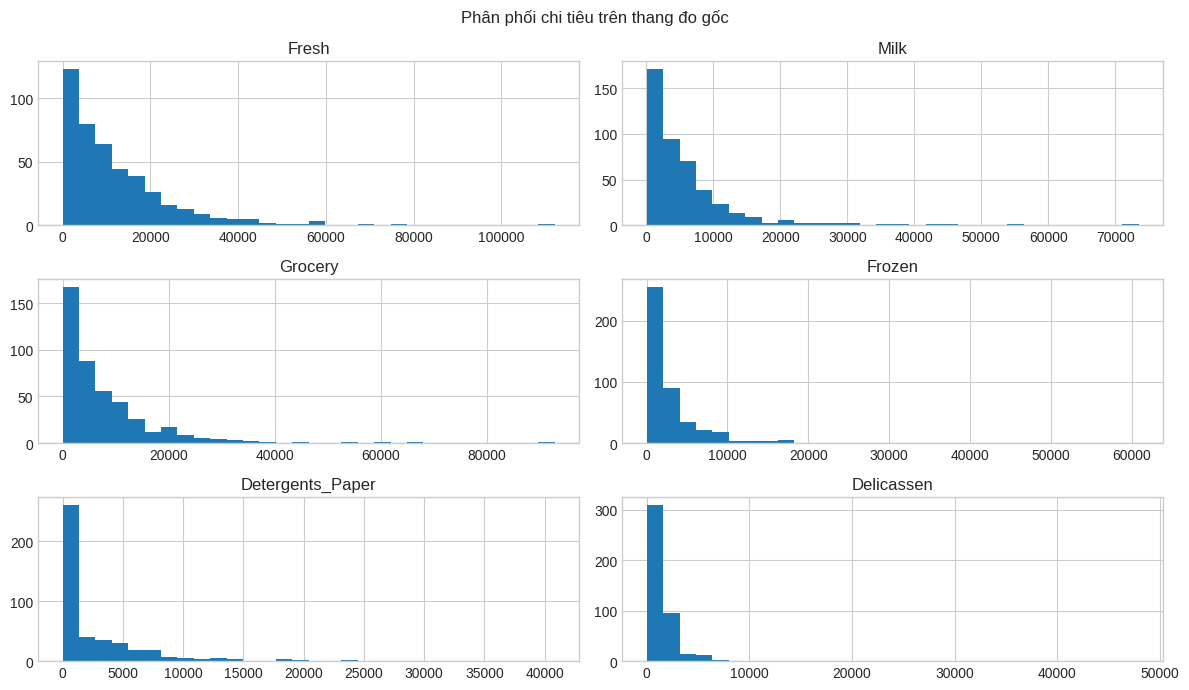

Nhận xét: Cả sáu phân phối đều lệch phải và có một số khách hàng chi tiêu rất lớn. Các điểm này có thể chi phối khoảng cách khi phân cụm.


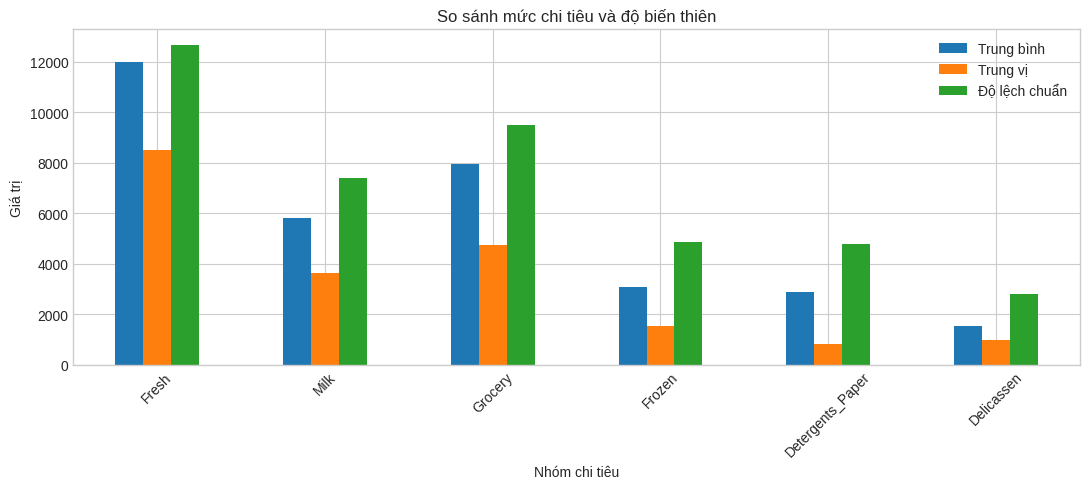

Nhận xét: Fresh có mức chi tiêu và độ biến thiên lớn, còn các feature khác có thang đo khác nhau. Vì vậy, cần scale dữ liệu để một feature lớn không lấn át các feature còn lại.


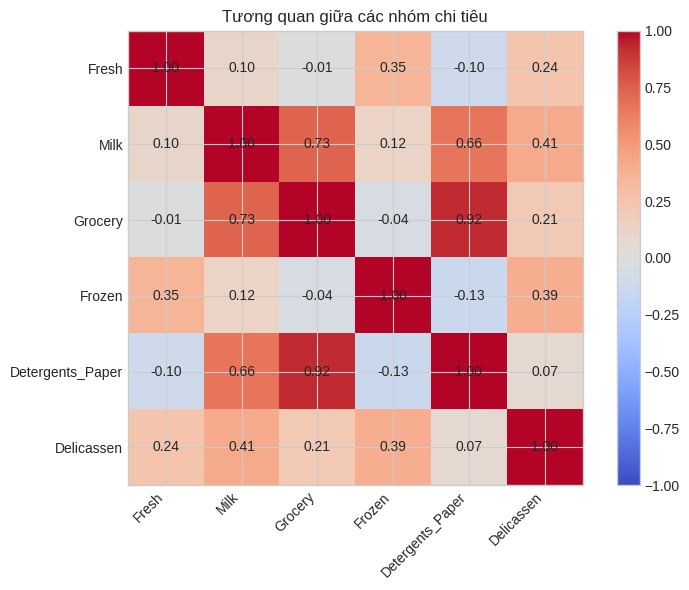

Nhận xét: Grocery có quan hệ mạnh với Detergents_Paper và Milk. Khi đọc profile cụm, nên xem ba feature này như một nhóm hành vi có liên quan.


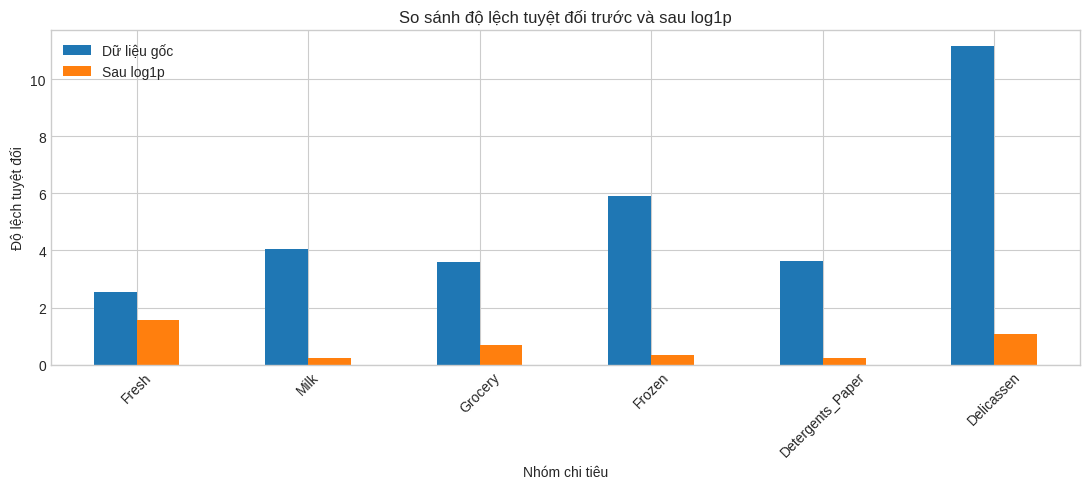

Nhận xét: log1p làm giảm rõ độ lệch và thu nhỏ ảnh hưởng của giá trị rất lớn. Phần sau nên thử log1p kết hợp scale, rồi so sánh K-Means với Agglomerative Clustering.


In [9]:
eda_summary = pd.DataFrame({
    'Trung bình': X_raw.mean(),
    'Trung vị': X_raw.median(),
    'Độ lệch chuẩn': X_raw.std(),
    'Hệ số biến thiên': X_raw.std() / X_raw.mean(),
    'Độ lệch phân phối': X_raw.skew()
})
display(eda_summary.round(2))

X_raw.hist(bins=30, figsize=(12, 7))
plt.suptitle('Phân phối chi tiêu trên thang đo gốc')
plt.tight_layout()
plt.show()
print('Nhận xét: Cả sáu phân phối đều lệch phải và có một số khách hàng chi tiêu rất lớn. Các điểm này có thể chi phối khoảng cách khi phân cụm.')

eda_summary[['Trung bình', 'Trung vị', 'Độ lệch chuẩn']].plot(kind='bar', figsize=(11, 5))
plt.title('So sánh mức chi tiêu và độ biến thiên')
plt.xlabel('Nhóm chi tiêu')
plt.ylabel('Giá trị')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('Nhận xét: Fresh có mức chi tiêu và độ biến thiên lớn, còn các feature khác có thang đo khác nhau. Vì vậy, cần scale dữ liệu để một feature lớn không lấn át các feature còn lại.')

correlation = X_raw.corr()
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(SPENDING_FEATURES)))
ax.set_yticks(range(len(SPENDING_FEATURES)))
ax.set_xticklabels(SPENDING_FEATURES, rotation=45, ha='right')
ax.set_yticklabels(SPENDING_FEATURES)
for row in range(len(SPENDING_FEATURES)):
    for column in range(len(SPENDING_FEATURES)):
        ax.text(column, row, f'{correlation.iloc[row, column]:.2f}', ha='center', va='center')
plt.colorbar(image)
plt.title('Tương quan giữa các nhóm chi tiêu')
plt.tight_layout()
plt.show()
print('Nhận xét: Grocery có quan hệ mạnh với Detergents_Paper và Milk. Khi đọc profile cụm, nên xem ba feature này như một nhóm hành vi có liên quan.')

X_log_eda = np.log1p(X_raw)
skew_comparison = pd.DataFrame({
    'Dữ liệu gốc': X_raw.skew().abs(),
    'Sau log1p': X_log_eda.skew().abs()
})
skew_comparison.plot(kind='bar', figsize=(11, 5))
plt.title('So sánh độ lệch tuyệt đối trước và sau log1p')
plt.xlabel('Nhóm chi tiêu')
plt.ylabel('Độ lệch tuyệt đối')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('Nhận xét: log1p làm giảm rõ độ lệch và thu nhỏ ảnh hưởng của giá trị rất lớn. Phần sau nên thử log1p kết hợp scale, rồi so sánh K-Means với Agglomerative Clustering.')


# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [10]:
X_log = np.log1p(X_raw)

raw_standard_scaler = StandardScaler()
log_standard_scaler = StandardScaler()
log_robust_scaler = RobustScaler()

X_raw_standard = pd.DataFrame(
    raw_standard_scaler.fit_transform(X_raw),
    columns=SPENDING_FEATURES,
    index=X_raw.index
)

X_log_standard = pd.DataFrame(
    log_standard_scaler.fit_transform(X_log),
    columns=SPENDING_FEATURES,
    index=X_raw.index
)

X_log_robust = pd.DataFrame(
    log_robust_scaler.fit_transform(X_log),
    columns=SPENDING_FEATURES,
    index=X_raw.index
)

preprocessing_comparison = pd.DataFrame({
    'Cách tiền xử lý': [
        'Dữ liệu gốc và StandardScaler',
        'log1p và StandardScaler',
        'log1p và RobustScaler'
    ],
    'Độ lệch tuyệt đối trung bình': [
        X_raw_standard.skew().abs().mean(),
        X_log_standard.skew().abs().mean(),
        X_log_robust.skew().abs().mean()
    ],
    'Độ lệch chuẩn nhỏ nhất': [
        X_raw_standard.std(ddof=0).min(),
        X_log_standard.std(ddof=0).min(),
        X_log_robust.std(ddof=0).min()
    ],
    'Độ lệch chuẩn lớn nhất': [
        X_raw_standard.std(ddof=0).max(),
        X_log_standard.std(ddof=0).max(),
        X_log_robust.std(ddof=0).max()
    ]
})
display(preprocessing_comparison.round(3))

X_model = X_log_standard.copy()

print('Ma trận dùng để huấn luyện mô hình: X_model = log1p và StandardScaler.')
print('log1p làm giảm độ lệch và thu nhỏ ảnh hưởng của các giá trị chi tiêu rất lớn.')
print('StandardScaler đưa sáu feature về thang đo tương đương để tính khoảng cách cân bằng hơn.')
print('X_raw vẫn được giữ nguyên để profile cụm bằng đơn vị chi tiêu gốc.')
print('Đánh đổi: log1p giúp mô hình bớt nhạy với ngoại lệ, nhưng khoảng cách sau biến đổi không còn thể hiểu trực tiếp bằng số tiền gốc.')


,Cách tiền xử lý,Độ lệch tuyệt đối trung bình,Độ lệch chuẩn nhỏ nhất,Độ lệch chuẩn lớn nhất
0,Dữ liệu gốc và StandardScaler,5.15,1.00,1.00
1,log1p và StandardScaler,0.69,1.00,1.00
2,log1p và RobustScaler,0.69,0.63,0.87


Ma trận dùng để huấn luyện mô hình: X_model = log1p và StandardScaler.
log1p làm giảm độ lệch và thu nhỏ ảnh hưởng của các giá trị chi tiêu rất lớn.
StandardScaler đưa sáu feature về thang đo tương đương để tính khoảng cách cân bằng hơn.
X_raw vẫn được giữ nguyên để profile cụm bằng đơn vị chi tiêu gốc.
Đánh đổi: log1p giúp mô hình bớt nhạy với ngoại lệ, nhưng khoảng cách sau biến đổi không còn thể hiểu trực tiếp bằng số tiền gốc.


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

,Thuật toán,Số cụm,Tiền xử lý,Tham số chính,Silhouette,Davies-Bouldin,Inertia,Kích thước cụm,Tỷ lệ nhiễu
0,K-Means,2,log1p và StandardScaler,n_init=20,0.29,1.35,"1,844.06","[188, 252]",0
1,Phân cụm phân cấp,2,log1p và StandardScaler,linkage=ward,0.26,1.60,NaN,"[178, 262]",0
2,K-Means,3,log1p và StandardScaler,n_init=20,0.26,1.35,"1,553.41","[83, 145, 212]",0
3,Phân cụm phân cấp,3,log1p và StandardScaler,linkage=ward,0.26,1.54,NaN,"[53, 125, 262]",0
4,K-Means,4,log1p và StandardScaler,n_init=20,0.19,1.54,"1,386.86","[61, 118, 129, 132]",0
5,Phân cụm phân cấp,4,log1p và StandardScaler,linkage=ward,0.20,1.52,NaN,"[53, 54, 125, 208]",0
6,K-Means,5,log1p và StandardScaler,n_init=20,0.19,1.48,"1,266.15","[54, 90, 96, 100, 100]",0
7,Phân cụm phân cấp,5,log1p và StandardScaler,linkage=ward,0.20,1.39,NaN,"[18, 35, 54, 125, 208]",0
8,K-Means,6,log1p và StandardScaler,n_init=20,0.20,1.41,"1,174.54","[15, 56, 83, 85, 91, 110]",0
9,Phân cụm phân cấp,6,log1p và StandardScaler,linkage=ward,0.17,1.49,NaN,"[18, 35, 54, 58, 125, 150]",0


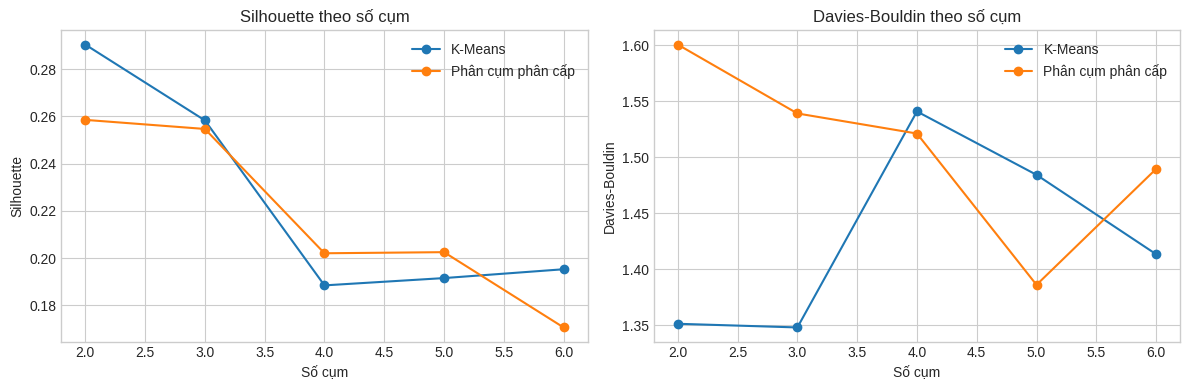

Nhận xét: K-Means với 2 cụm có Silhouette cao nhất trong các cấu hình đã thử, hai cụm đều có quy mô đủ lớn và không có nhiễu.
Phân cụm phân cấp được giữ làm mô hình đối chiếu, nhưng không được chọn vì Silhouette thấp hơn ở cấu hình 2 cụm.
Các cấu hình nhiều hơn 2 cụm không được giữ lại vì không cải thiện Silhouette một cách thuyết phục.


In [11]:
model_results = []
candidate_labels = {}

for number_of_clusters in range(2, 7):
    kmeans_model = KMeans(
        n_clusters=number_of_clusters,
        n_init=20,
        random_state=RANDOM_STATE
    )
    kmeans_labels = kmeans_model.fit_predict(X_model)
    candidate_labels[f'K-Means, k={number_of_clusters}'] = kmeans_labels
    model_results.append({
        'Thuật toán': 'K-Means',
        'Số cụm': number_of_clusters,
        'Tiền xử lý': 'log1p và StandardScaler',
        'Tham số chính': 'n_init=20',
        'Silhouette': silhouette_score(X_model, kmeans_labels),
        'Davies-Bouldin': davies_bouldin_score(X_model, kmeans_labels),
        'Inertia': kmeans_model.inertia_,
        'Kích thước cụm': sorted(pd.Series(kmeans_labels).value_counts().tolist()),
        'Tỷ lệ nhiễu': 0
    })

    hierarchical_model = AgglomerativeClustering(
        n_clusters=number_of_clusters,
        linkage='ward'
    )
    hierarchical_labels = hierarchical_model.fit_predict(X_model)
    candidate_labels[f'Phân cụm phân cấp, k={number_of_clusters}'] = hierarchical_labels
    model_results.append({
        'Thuật toán': 'Phân cụm phân cấp',
        'Số cụm': number_of_clusters,
        'Tiền xử lý': 'log1p và StandardScaler',
        'Tham số chính': 'linkage=ward',
        'Silhouette': silhouette_score(X_model, hierarchical_labels),
        'Davies-Bouldin': davies_bouldin_score(X_model, hierarchical_labels),
        'Inertia': np.nan,
        'Kích thước cụm': sorted(pd.Series(hierarchical_labels).value_counts().tolist()),
        'Tỷ lệ nhiễu': 0
    })

model_results = pd.DataFrame(model_results)
display(model_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for algorithm_name in model_results['Thuật toán'].unique():
    algorithm_rows = model_results[model_results['Thuật toán'] == algorithm_name]
    axes[0].plot(algorithm_rows['Số cụm'], algorithm_rows['Silhouette'], marker='o', label=algorithm_name)
    axes[1].plot(algorithm_rows['Số cụm'], algorithm_rows['Davies-Bouldin'], marker='o', label=algorithm_name)
axes[0].set_title('Silhouette theo số cụm')
axes[0].set_xlabel('Số cụm')
axes[0].set_ylabel('Silhouette')
axes[0].legend()
axes[1].set_title('Davies-Bouldin theo số cụm')
axes[1].set_xlabel('Số cụm')
axes[1].set_ylabel('Davies-Bouldin')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Nhận xét: K-Means với 2 cụm có Silhouette cao nhất trong các cấu hình đã thử, hai cụm đều có quy mô đủ lớn và không có nhiễu.')
print('Phân cụm phân cấp được giữ làm mô hình đối chiếu, nhưng không được chọn vì Silhouette thấp hơn ở cấu hình 2 cụm.')
print('Các cấu hình nhiều hơn 2 cụm không được giữ lại vì không cải thiện Silhouette một cách thuyết phục.')


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [12]:
final_model = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
labels_final = final_model.fit_predict(X_model)

final_silhouette = silhouette_score(X_model, labels_final)
final_davies_bouldin = davies_bouldin_score(X_model, labels_final)
final_sizes = pd.Series(labels_final).value_counts().sort_index()

seed_results = []
for seed in [0, 1, 7, 21, 99]:
    seed_model = KMeans(n_clusters=2, n_init=20, random_state=seed)
    seed_labels = seed_model.fit_predict(X_model)
    seed_results.append({
        'Hạt giống ngẫu nhiên': seed,
        'ARI so với mô hình cuối': adjusted_rand_score(labels_final, seed_labels)
    })

seed_results = pd.DataFrame(seed_results)
display(seed_results.round(3))

robust_model = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
robust_labels = robust_model.fit_predict(X_log_robust)
robust_ari = adjusted_rand_score(labels_final, robust_labels)

evaluation_summary = pd.DataFrame({
    'Chỉ số': [
        'Silhouette',
        'Davies-Bouldin',
        'ARI trung bình khi đổi hạt giống',
        'ARI khi đổi sang RobustScaler'
    ],
    'Giá trị': [
        final_silhouette,
        final_davies_bouldin,
        seed_results['ARI so với mô hình cuối'].mean(),
        robust_ari
    ]
})
display(evaluation_summary.round(3))
display(final_sizes.rename('Số khách hàng').to_frame())

print('Mô hình cuối: K-Means, n_clusters=2, n_init=20, random_state=42.')
print(f'Bằng chứng mạnh nhất: Silhouette = {final_silhouette:.3f}, cao nhất trong các cấu hình đã thử.')
print(f'Hai cụm có {final_sizes.iloc[0]} và {final_sizes.iloc[1]} khách hàng, nên không có cụm quá nhỏ.')
print(f'ARI khi đổi sang RobustScaler = {robust_ari:.3f}, cho thấy kết quả khá bền vững với cách scale hợp lý khác.')
print('Điều chưa chắc chắn: Silhouette chỉ ở mức vừa phải, nên ranh giới giữa hai cụm không hoàn toàn tách biệt.')


,Hạt giống ngẫu nhiên,ARI so với mô hình cuối
0,0,1.00
1,1,1.00
2,7,1.00
3,21,1.00
4,99,1.00


,Chỉ số,Giá trị
0,Silhouette,0.29
1,Davies-Bouldin,1.35
2,ARI trung bình khi đổi hạt giống,1.00
3,ARI khi đổi sang RobustScaler,0.93


,Số khách hàng
0,252
1,188


Mô hình cuối: K-Means, n_clusters=2, n_init=20, random_state=42.
Bằng chứng mạnh nhất: Silhouette = 0.290, cao nhất trong các cấu hình đã thử.
Hai cụm có 252 và 188 khách hàng, nên không có cụm quá nhỏ.
ARI khi đổi sang RobustScaler = 0.928, cho thấy kết quả khá bền vững với cách scale hợp lý khác.
Điều chưa chắc chắn: Silhouette chỉ ở mức vừa phải, nên ranh giới giữa hai cụm không hoàn toàn tách biệt.


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


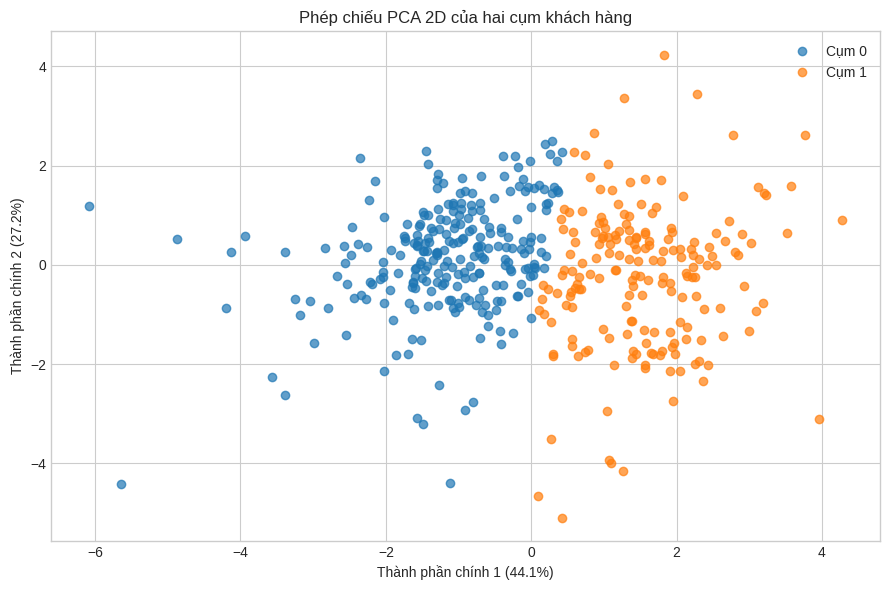

Hai trục PCA giữ lại 71.3% phương sai của ma trận 6 chiều.
Biểu đồ giúp quan sát xu hướng tách và phần chồng lấn của hai cụm.
K-Means được huấn luyện trên đủ 6 chiều của X_model, không phải trên hai trục PCA.
Giới hạn: PCA 2D làm mất một phần thông tin, nên hình này không thể tự nó chứng minh các cụm tách biệt hoàn hảo.


In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(X_model)
explained_variance = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(9, 6))
for cluster_number in sorted(np.unique(labels_final)):
    cluster_mask = labels_final == cluster_number
    plt.scatter(
        pca_coordinates[cluster_mask, 0],
        pca_coordinates[cluster_mask, 1],
        label=f'Cụm {cluster_number}',
        alpha=0.7
    )
plt.xlabel(f'Thành phần chính 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'Thành phần chính 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.title('Phép chiếu PCA 2D của hai cụm khách hàng')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Hai trục PCA giữ lại {explained_variance * 100:.1f}% phương sai của ma trận 6 chiều.')
print('Biểu đồ giúp quan sát xu hướng tách và phần chồng lấn của hai cụm.')
print('K-Means được huấn luyện trên đủ 6 chiều của X_model, không phải trên hai trục PCA.')
print('Giới hạn: PCA 2D làm mất một phần thông tin, nên hình này không thể tự nó chứng minh các cụm tách biệt hoàn hảo.')


# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

,Tên cụm,Số khách hàng,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cụm,,,,,,,,
0,Ưu tiên thực phẩm tươi,252,"10,348.00","1,871.00","2,406.00","2,225.00",328.00,750.00
1,Bán lẻ nhu yếu phẩm,188,"5,406.00","7,690.00","11,527.00","1,062.00","4,495.00","1,388.00"


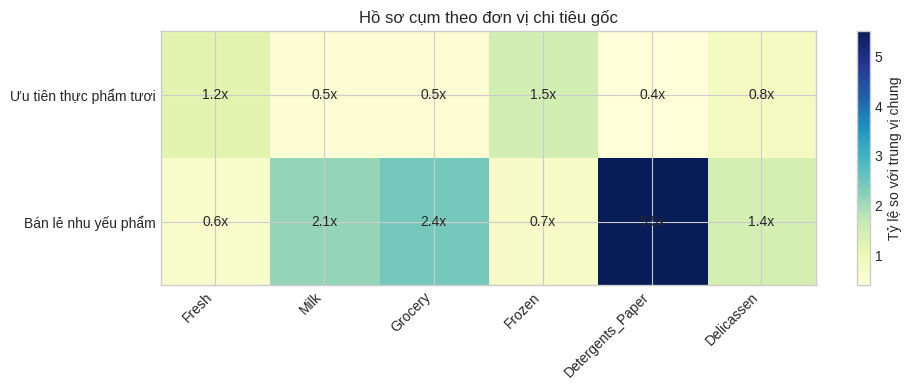

Tỷ lệ Channel trong từng cụm (%), chỉ dùng để kiểm tra sau phân cụm:


Channel,1,2
Tên cụm,,
Bán lẻ nhu yếu phẩm,28.70,71.30
Ưu tiên thực phẩm tươi,96.80,3.20


Cụm “Ưu tiên thực phẩm tươi” có trung vị Fresh = 10,348 và Frozen = 2,225, trong khi Grocery chỉ = 2,406.
Giả thuyết hành động: thử gói Fresh kèm Frozen hoặc lịch giao hàng phù hợp; đo giá trị đơn, lợi nhuận và tỷ lệ mua lại so với nhóm đối chứng.
Cụm “Bán lẻ nhu yếu phẩm” có trung vị Milk = 7,690, Grocery = 11,527 và Detergents_Paper = 4,495.
Giả thuyết hành động: thử gói Milk, Grocery và Detergents_Paper theo sản lượng; đo mức tăng doanh thu, biên lợi nhuận và tỷ lệ phản hồi.
Dữ liệu còn thiếu trước khi ra quyết định: lợi nhuận, tần suất mua, thời gian giao dịch, quy mô khách hàng và phản hồi chiến dịch.


In [14]:
profile_data = X_raw.copy()
profile_data['Cụm'] = labels_final
profile_median = profile_data.groupby('Cụm')[SPENDING_FEATURES].median()
profile_mean = profile_data.groupby('Cụm')[SPENDING_FEATURES].mean()
profile_sizes = profile_data['Cụm'].value_counts().sort_index()

fresh_cluster = profile_median['Grocery'].idxmin()
grocery_cluster = profile_median['Grocery'].idxmax()
cluster_names = {
    fresh_cluster: 'Ưu tiên thực phẩm tươi',
    grocery_cluster: 'Bán lẻ nhu yếu phẩm'
}
profile_data['Tên cụm'] = profile_data['Cụm'].map(cluster_names)

profile_table = profile_median.copy()
profile_table.insert(0, 'Tên cụm', profile_table.index.map(cluster_names))
profile_table.insert(1, 'Số khách hàng', profile_sizes)
display(profile_table.round(0))

profile_ratio = profile_median.divide(X_raw.median())
fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(profile_ratio, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(SPENDING_FEATURES)))
ax.set_xticklabels(SPENDING_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(len(profile_ratio)))
ax.set_yticklabels([cluster_names[number] for number in profile_ratio.index])
for row in range(profile_ratio.shape[0]):
    for column in range(profile_ratio.shape[1]):
        ax.text(column, row, f'{profile_ratio.iloc[row, column]:.1f}x', ha='center', va='center')
plt.colorbar(image, label='Tỷ lệ so với trung vị chung')
plt.title('Hồ sơ cụm theo đơn vị chi tiêu gốc')
plt.tight_layout()
plt.show()

if 'Channel' in df.columns:
    channel_check = pd.crosstab(
        profile_data['Tên cụm'],
        df['Channel'],
        normalize='index'
    ) * 100
    print('Tỷ lệ Channel trong từng cụm (%), chỉ dùng để kiểm tra sau phân cụm:')
    display(channel_check.round(1))

print(f'Cụm “{cluster_names[fresh_cluster]}” có trung vị Fresh = {profile_median.loc[fresh_cluster].Fresh:,.0f} và Frozen = {profile_median.loc[fresh_cluster].Frozen:,.0f}, trong khi Grocery chỉ = {profile_median.loc[fresh_cluster].Grocery:,.0f}.')
print('Giả thuyết hành động: thử gói Fresh kèm Frozen hoặc lịch giao hàng phù hợp; đo giá trị đơn, lợi nhuận và tỷ lệ mua lại so với nhóm đối chứng.')
print(f'Cụm “{cluster_names[grocery_cluster]}” có trung vị Milk = {profile_median.loc[grocery_cluster].Milk:,.0f}, Grocery = {profile_median.loc[grocery_cluster].Grocery:,.0f} và Detergents_Paper = {profile_median.loc[grocery_cluster].Detergents_Paper:,.0f}.')
print('Giả thuyết hành động: thử gói Milk, Grocery và Detergents_Paper theo sản lượng; đo mức tăng doanh thu, biên lợi nhuận và tỷ lệ phản hồi.')
print('Dữ liệu còn thiếu trước khi ra quyết định: lợi nhuận, tần suất mua, thời gian giao dịch, quy mô khách hàng và phản hồi chiến dịch.')


# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


### Tóm tắt điều hành (TODO H)

Khuyến nghị hiện tại là **thử nghiệm giới hạn**, chưa dùng phân khúc này để đưa ra quyết định lớn. Mô hình cuối là K-Means với 2 cụm, `n_init=20` và `random_state=42`, được huấn luyện trên sáu cột chi tiêu sau `log1p` và `StandardScaler`. Cấu hình này có Silhouette 0,290, cao nhất trong các thử nghiệm, hai cụm có quy mô 252 và 188 khách hàng. Nhãn không thay đổi khi đổi hạt giống và vẫn rất giống khi thay `StandardScaler` bằng `RobustScaler` (ARI 0,928).

Cụm **Ưu tiên thực phẩm tươi** có chi tiêu Fresh và Frozen cao hơn nhưng Milk, Grocery và Detergents_Paper thấp. Cụm **Bán lẻ nhu yếu phẩm** thể hiện mẫu ngược lại, nổi bật ở Milk, Grocery và Detergents_Paper.

Thử nghiệm đầu tiên nên là gói Fresh kèm Frozen cho cụm thứ nhất và gói Milk–Grocery–Detergents_Paper theo sản lượng cho cụm thứ hai. Cần chia ngẫu nhiên nhóm thử và đối chứng, sau đó so sánh doanh thu, lợi nhuận và tỷ lệ mua lại. Giới hạn quan trọng nhất là dữ liệu chỉ có tổng chi tiêu hằng năm; chưa có lợi nhuận, thời gian, tần suất hay phản hồi chiến dịch.